# Setup Steps

## Imports

In [2]:
import cv2
import numpy as np
import psycopg2
import json
import os
import urllib.request
from datetime import datetime
import time
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.widgets import Button
from IPython.display import display, clear_output
from deepface import DeepFace

## Creating the database 

Define database credentials

In [3]:

DB_HOST = "localhost"
DB_PORT = 5432
DB_NAME = "retail_cv_deep_dive"
DB_USER = "postgres"
DB_PASSWORD = "abc123"

In [4]:
conn = psycopg2.connect(
    host=DB_HOST,
    port=DB_PORT,
    dbname=DB_NAME,
    user=DB_USER,
    password=DB_PASSWORD
)
cursor = conn.cursor()
print("Database connection successful.")

Database connection successful.


Create the database connection and define the table structure.

In [ ]:

# create zones table
cursor.execute("""
    CREATE TABLE IF NOT EXISTS zones (
        zone_id               SERIAL PRIMARY KEY,
        zone_name             VARCHAR(100),
        camera_id             VARCHAR(50),
        polygon_coordinates   JSONB,
        floor                 VARCHAR(20),
        zone_type             VARCHAR(50),
        UNIQUE (zone_name, camera_id)       
    )
""")
print("Zones table created.")

#create rules table
cursor.execute("""
    CREATE TABLE IF NOT EXISTS rules (
        rule_id               SERIAL PRIMARY KEY,
        rule_name             VARCHAR(100),
        zone_id               INT REFERENCES zones(zone_id),
        trigger_condition     VARCHAR(255),
        threshold_min         FLOAT,
        threshold_max         FLOAT,
        severity              VARCHAR(20),
        rule_type             VARCHAR(50),
        active                BOOLEAN DEFAULT TRUE
    )
""")
print("Rules table created.")

cursor.execute("""
    CREATE TABLE IF NOT EXISTS detection_events (
        unique_detection_id   SERIAL PRIMARY KEY,
        timestamp             TIMESTAMP,
        frame_number          INT,
        camera_id             VARCHAR(50),
        zone_id               INT REFERENCES zones(zone_id),
        polygon_zone_id       INT REFERENCES zones(zone_id),
        model_name            VARCHAR(100),
        object_class          VARCHAR(50),
        confidence            FLOAT,
        bbox                  JSONB,
        track_id              VARCHAR(50),
        reid_type             VARCHAR(20),
        reid_id               VARCHAR(50),
        previous_zone_id      INT REFERENCES zones(zone_id),
        movement_type         VARCHAR(20),
        direction             VARCHAR(20),
        dwell_time            FLOAT,
        object_count_in_zone  INT,
        processing_latency    FLOAT
    )
""")
print("Detection events table created.")

cursor.execute("""
    CREATE TABLE IF NOT EXISTS emotion_events (
        unique_detection_id   INT REFERENCES detection_events(unique_detection_id),
        emotion               VARCHAR(50),
        confidence            FLOAT,
        bbox                  JSONB
    )
""")
print("Emotion events table created.")

cursor.execute("""
    CREATE TABLE IF NOT EXISTS notifications (
        notification_id       SERIAL PRIMARY KEY,
        timestamp             TIMESTAMP,
        rule_id               INT REFERENCES rules(rule_id),
        unique_detection_id   INT REFERENCES detection_events(unique_detection_id),
        zone_id               INT REFERENCES zones(zone_id),
        camera_id             VARCHAR(50),
        trigger_value         JSONB,
        message               VARCHAR(255)
    )
""")
print("Notifications table created.")

conn.commit()
print("All 5 tables ready.")

Database connection successful.
Zones table created.
Rules table created.
Detection events table created.
Emotion events table created.
Notifications table created.
All 5 tables ready.


## Inference Configuration

In [38]:
#Paths
INPUT_VIDEO_PATH  = "Input_Videos/Emotion_Classification/Emotion_video_1.mp4"
OUTPUT_VIDEO_PATH = "Output_Videos/Emotion_Classification/Output_2.mp4"
MODEL_DIR         = "models/"

# Ensure local directories exist for the configured paths
os.makedirs(os.path.dirname(INPUT_VIDEO_PATH), exist_ok=True)
os.makedirs(os.path.dirname(OUTPUT_VIDEO_PATH), exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

#Camera naming
CAMERA_ID = "CAM_01"

#Confidence Thresholds
PEOPLENET_CONFIDENCE_THRESHOLD = 0.5
EMOTION_CONFIDENCE_THRESHOLD   = 0.5

#Toggle
SAVE_OUTPUT_VIDEO = True
SHOW_LIVE_PREVIEW = False
DB_WRITE_ENABLED  = True

## Helper Functions

In [32]:
# ── DATABASE ───────────────────────────────────────────────────────────────
cursor = conn.cursor()

def write_detection_event(
    frame_number, camera_id, zone_id, polygon_zone_id,
    model_name, object_class, confidence, bbox,
    track_id=None, reid_type=None, reid_id=None,
    previous_zone_id=None, movement_type=None,
    direction=None, dwell_time=None,
    object_count_in_zone=None, processing_latency=None
):
    """Insert a detection event and return its unique_detection_id."""
    if not DB_WRITE_ENABLED:
        return None
    cursor.execute("""
        INSERT INTO detection_events (
            timestamp, frame_number, camera_id, zone_id, polygon_zone_id,
            model_name, object_class, confidence, bbox, track_id,
            reid_type, reid_id, previous_zone_id, movement_type,
            direction, dwell_time, object_count_in_zone, processing_latency
        ) VALUES (
            %s, %s, %s, %s, %s,
            %s, %s, %s, %s, %s,
            %s, %s, %s, %s,
            %s, %s, %s, %s
        ) RETURNING unique_detection_id
    """, (
        datetime.now(), frame_number, camera_id, zone_id, polygon_zone_id,
        model_name, object_class, float(confidence), json.dumps(bbox), track_id,
        reid_type, reid_id, previous_zone_id, movement_type,
        direction, dwell_time, object_count_in_zone, float(processing_latency) if processing_latency else None
    ))
    conn.commit()
    return cursor.fetchone()[0]


def write_emotion_event(unique_detection_id, emotion, confidence, bbox):
    """Insert an emotion event linked to a detection event."""
    if not DB_WRITE_ENABLED:
        return
    cursor.execute("""
        INSERT INTO emotion_events (unique_detection_id, emotion, confidence, bbox)
        VALUES (%s, %s, %s, %s)
    """, (
        unique_detection_id,
        emotion,
        float(confidence),        # convert numpy.float32 to Python float
        json.dumps(bbox)
    ))
    conn.commit()


def write_notification(rule_id, unique_detection_id, zone_id, camera_id, trigger_value, message):
    """Insert a notification event."""
    if not DB_WRITE_ENABLED:
        return
    cursor.execute("""
        INSERT INTO notifications 
        (timestamp, rule_id, unique_detection_id, zone_id, camera_id, trigger_value, message)
        VALUES (%s, %s, %s, %s, %s, %s, %s)
    """, (
        datetime.now(),
        rule_id,
        unique_detection_id,
        zone_id,
        camera_id,
        json.dumps(trigger_value),
        message
    ))
    conn.commit()


# ── GEOMETRY ───────────────────────────────────────────────────────────────

def point_in_polygon(point, polygon):
    """Check if a point (x, y) is inside a polygon using ray casting."""
    x, y = point
    n = len(polygon)
    inside = False
    px, py = polygon[0]
    for i in range(1, n + 1):
        cx, cy = polygon[i % n]
        if ((py > y) != (cy > y)) and (x < (cx - px) * (y - py) / (cy - py) + px):
            inside = not inside
        px, py = cx, cy
    return inside


def get_bbox_center_normalized(bbox, frame_width, frame_height):
    """Return the normalized center point of a bounding box."""
    cx = ((bbox["x1"] + bbox["x2"]) / 2) / frame_width
    cy = ((bbox["y1"] + bbox["y2"]) / 2) / frame_height
    return (cx, cy)


def get_direction(prev_center, curr_center):
    """Return movement direction based on two center points."""
    dx = curr_center[0] - prev_center[0]
    dy = curr_center[1] - prev_center[1]
    if abs(dx) > abs(dy):
        return "right" if dx > 0 else "left"
    else:
        return "down" if dy > 0 else "up"


# ── DRAWING ────────────────────────────────────────────────────────────────

def draw_overlay(frame, bbox, label, color=(0, 255, 0)):
    """Draw bounding box and label on a frame."""
    x1, y1, x2, y2 = bbox["x1"], bbox["y1"], bbox["x2"], bbox["y2"]

    # Draw bounding box
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

    # Draw label background for readability
    label_size, _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    cv2.rectangle(frame,
                  (x1, y1 - label_size[1] - 6),
                  (x1 + label_size[0], y1),
                  color, -1)

    # Draw label text in black on coloured background
    cv2.putText(frame, label, (x1, y1 - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    return frame


def draw_polygon_zones(frame, polygon_zones):
    """Draw all defined polygon zones on a frame."""
    for zone in polygon_zones:
        pts = np.array(zone["polygon_coordinates"]["points"], np.int32)
        pts = pts.reshape((-1, 1, 2))
        cv2.polylines(frame, [pts], isClosed=True, color=(255, 165, 0), thickness=2)
        cx = int(np.mean([p[0] for p in zone["polygon_coordinates"]["points"]]))
        cy = int(np.mean([p[1] for p in zone["polygon_coordinates"]["points"]]))
        cv2.putText(frame, zone["zone_name"], (cx, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 165, 0), 2)
    return frame


# ── EMOTION ────────────────────────────────────────────────────────────────

def classify_emotion(face_crop):
    """
    Run DeepFace emotion classification on a face crop.
    Returns dominant_emotion and its normalised confidence (0-1).
    DeepFace docs: https://pypi.org/project/deepface/
    """
    try:
        result = DeepFace.analyze(
            img_path         = face_crop,
            actions          = ["emotion"],
            enforce_detection = False,
            silent           = True
        )
        dominant_emotion = result[0]["dominant_emotion"]
        confidence       = result[0]["emotion"][dominant_emotion] / 100
        return dominant_emotion, confidence

    except Exception as e:
        return None, None


def crop_face(frame, bbox):
    """Crop a face region from a frame using bounding box coordinates."""
    x1, y1, x2, y2 = bbox["x1"], bbox["y1"], bbox["x2"], bbox["y2"]
    return frame[y1:y2, x1:x2]

# DetectNet_v2 grid settings matching PeopleNet input size 960x544
GRID_W      = 60
GRID_H      = 34
INPUT_W     = 960
INPUT_H     = 544
NUM_CLASSES = 3
class_map   = {0: "person", 1: "bag", 2: "face"}

def parse_peoplenet_detections(bbox_output, cov_output, confidence_threshold, orig_w, orig_h):
    """
    Parse PeopleNet DetectNet_v2 ONNX output.
    Source: https://github.com/NVIDIA-TAO/tao-deploy/blob/main/nvidia_tao_deploy/cv/detectnet_v2/postprocessor.py
    
    When train_img_size is not set, it defaults to bbox_norm = (35, 35).
    gc_centers are divided by bbox_norm, then bbox values subtract/add gc_centers,
    then multiply by train_img_size (35) to get pixel coordinates at model input scale,
    then scale to original frame size.
    """
    detections  = []
    stride      = 16
    bbox_norm   = 35.0
    bbox_offset = 0.5
    scale_x     = orig_w / INPUT_W
    scale_y     = orig_h / INPUT_H

    gc_centers_x = (np.arange(GRID_W) * stride + bbox_offset) / bbox_norm
    gc_centers_y = (np.arange(GRID_H) * stride + bbox_offset) / bbox_norm

    for cls_id in range(NUM_CLASSES):
        confidences = cov_output[0, cls_id]
        bbox_ch     = bbox_output[0, cls_id * 4: cls_id * 4 + 4]

        for row in range(GRID_H):
            for col in range(GRID_W):
                conf = float(confidences[row, col])
                if conf < confidence_threshold:
                    continue

                gcx = gc_centers_x[col]
                gcy = gc_centers_y[row]

                raw_x1 = float(bbox_ch[0, row, col])
                raw_y1 = float(bbox_ch[1, row, col])
                raw_x2 = float(bbox_ch[2, row, col])
                raw_y2 = float(bbox_ch[3, row, col])

                # Subtract gc_center then multiply by -bbox_norm for x1/y1
                # Add gc_center then multiply by bbox_norm for x2/y2
                # Then scale to original frame dimensions
                x1 = int((raw_x1 - gcx) * -bbox_norm * scale_x)
                y1 = int((raw_y1 - gcy) * -bbox_norm * scale_y)
                x2 = int((raw_x2 + gcx) *  bbox_norm * scale_x)
                y2 = int((raw_y2 + gcy) *  bbox_norm * scale_y)

                # Clamp to frame bounds
                x1 = max(0, min(x1, orig_w))
                y1 = max(0, min(y1, orig_h))
                x2 = max(0, min(x2, orig_w))
                y2 = max(0, min(y2, orig_h))

                if x2 <= x1 or y2 <= y1:
                    continue

                detections.append({
                    "object_class" : class_map[cls_id],
                    "confidence"   : conf,
                    "bbox"         : {"x1": x1, "y1": y1, "x2": x2, "y2": y2}
                })

    return detections

def apply_nms(detections, iou_threshold=0.3):
    """
    Apply Non-Maximum Suppression to remove overlapping detections.
    Groups by object_class and suppresses lower-confidence overlapping boxes.
    """
    if not detections:
        return []
    
    # Filter out zero-size boxes first
    detections = [
        d for d in detections
        if d["bbox"]["x2"] > d["bbox"]["x1"] and d["bbox"]["y2"] > d["bbox"]["y1"]
    ]
    
    # Group by class
    class_groups = {}
    for det in detections:
        cls = det["object_class"]
        if cls not in class_groups:
            class_groups[cls] = []
        class_groups[cls].append(det)

    results = []

    for cls, dets in class_groups.items():
        # Sort by confidence descending
        dets = sorted(dets, key=lambda x: x["confidence"], reverse=True)
        kept = []

        while dets:
            best = dets.pop(0)
            kept.append(best)
            dets = [
                d for d in dets
                if compute_iou(best["bbox"], d["bbox"]) < iou_threshold
            ]

        results.extend(kept)

    return results


def compute_iou(boxA, boxB):
    """Compute Intersection over Union between two bounding boxes."""
    xA = max(boxA["x1"], boxB["x1"])
    yA = max(boxA["y1"], boxB["y1"])
    xB = min(boxA["x2"], boxB["x2"])
    yB = min(boxA["y2"], boxB["y2"])

    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0

    areaA = (boxA["x2"] - boxA["x1"]) * (boxA["y2"] - boxA["y1"])
    areaB = (boxB["x2"] - boxB["x1"]) * (boxB["y2"] - boxB["y1"])
    union = areaA + areaB - inter

    return inter / union if union > 0 else 0.0


print("Global functions loaded.")

Global functions loaded.


# Emotion Classification

Load PeopleNet model

In [8]:
import deepface
print(deepface.__file__)

c:\Users\Kayana\Desktop\Computer-Vision-YT\retail-deep-dive-computer-vision\venv\Lib\site-packages\deepface\__init__.py


In [9]:
PEOPLENET_MODEL_PATH = os.path.join(MODEL_DIR, "resnet34_peoplenet.onnx")

if not os.path.exists(PEOPLENET_MODEL_PATH):
    print("PeopleNet model not found.")
    print("Download from: https://catalog.ngc.nvidia.com/orgs/nvidia/teams/tao/models/peoplenet")
    print(f"Place the ONNX file at: {PEOPLENET_MODEL_PATH}")
else:
    peoplenet = cv2.dnn.readNetFromONNX(PEOPLENET_MODEL_PATH)
    print("PeopleNet loaded.")

# DeepFace downloads weights automatically on first run
print(f"DeepFace version: {deepface.__version__}")
print("DeepFace ready. Weights will download automatically on first inference call.")

PeopleNet loaded.
DeepFace version: 0.0.100
DeepFace ready. Weights will download automatically on first inference call.


## Polygon Zone setup

Step 1: Extracting the first frame of your video

In [13]:
ZONE_SETUP_DIR         = "zone_setup_frames/"
os.makedirs(os.path.dirname(ZONE_SETUP_DIR), exist_ok=True)

In [14]:
cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
ret, first_frame = cap.read()
cap.release()

if ret:
    cv2.imwrite(os.path.join(ZONE_SETUP_DIR, "zone_setup_frame_emotion_detection.jpg"), first_frame)
    print("Frame saved as zone_setup_frame_emotion_detection.jpg")

Frame saved as zone_setup_frame_emotion_detection.jpg


Step 2: Draw Zones using https://polygonzone.roboflow.com . Upload the extracted first frame, draw your zones, and copy the NORMALIZED coordinates output.

Step 3: Add zones here with their metadata before running the inference loop

In [13]:
#DEFINE ZONES 

zones = [
    {
        "zone_name"           : "Atrium_Walkway",
        "camera_id"           : "CAM_01",
        "polygon_coordinates" : [np.array([[0.06, 0.21], [0.97, 0.18], [0.97, 0.95], [0.06, 0.93]])],   # paste the coordinates from the drawing tool here
        "floor"               : "L1",
        "zone_type"           : "shopping_area"
    }
]


In [16]:
# ── CONVERT NUMPY ARRAYS TO PLAIN DICT ────────────────────────────────────
def convert_polygon_coordinates(raw):
    """
    Converts Roboflow output format [np.array([[x,y], ...])]
    to plain dict {"points": [[x,y], ...]}
    """
    if isinstance(raw, dict):
        return raw  
    if isinstance(raw, list) and len(raw) > 0 and isinstance(raw[0], np.ndarray):
        return {"points": raw[0].tolist()}
    return raw

for zone in zones:
    zone["polygon_coordinates"] = convert_polygon_coordinates(zone["polygon_coordinates"])

print("Zones after conversion:")
for zone in zones:
    print(f"  {zone['zone_name']}: {zone['polygon_coordinates']}")

# Insert zones into database
for zone in zones:
    cursor.execute("""
        UPDATE zones
        SET polygon_coordinates = %s
        WHERE zone_name = %s AND camera_id = %s
    """, (
        json.dumps(zone["polygon_coordinates"]),
        zone["zone_name"],
        zone["camera_id"]
    ))

conn.commit()
print("Coordinates updated.")


Zones after conversion:
  Atrium_Walkway: {'points': [[0.06, 0.21], [0.97, 0.18], [0.97, 0.95], [0.06, 0.93]]}
Coordinates updated.


Step 4: Verify Zones

Reloaded 1 zones:
  Atrium_Walkway — coordinates: {'points': [[0.06, 0.21], [0.97, 0.18], [0.97, 0.95], [0.06, 0.93]]}


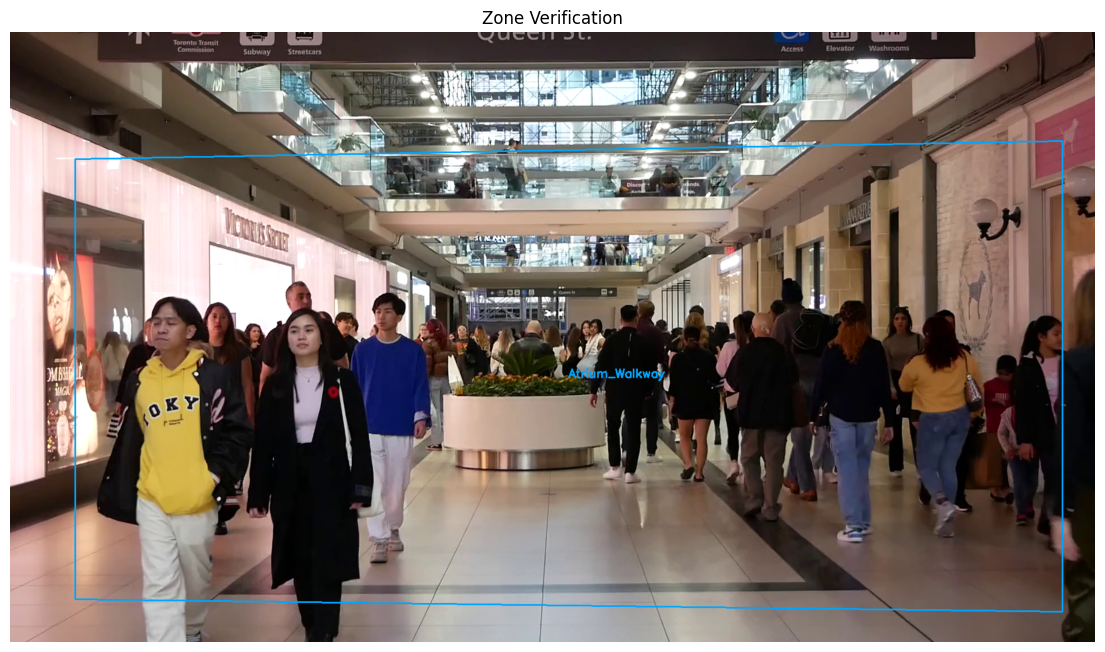

In [15]:
polygon_zones = []
cursor.execute("""
    SELECT zone_id, zone_name, zone_type, floor, polygon_coordinates
    FROM zones
    WHERE camera_id = %s
""", (CAMERA_ID,))
rows = cursor.fetchall()

for row in rows:
    polygon_zones.append({
        "zone_id"             : row[0],
        "zone_name"           : row[1],
        "zone_type"           : row[2],
        "floor"               : row[3],
        "polygon_coordinates" : row[4]
    })

print(f"Reloaded {len(polygon_zones)} zones:")
for z in polygon_zones:
    print(f"  {z['zone_name']} — coordinates: {z['polygon_coordinates']}")
    
verify_frame = first_frame.copy()
h, w = verify_frame.shape[:2]

for z in polygon_zones:
    if z["polygon_coordinates"] is None:
        print(f"Skipping zone '{z['zone_name']}' — no coordinates defined.")
        continue

    pts = z["polygon_coordinates"]["points"]
    pixel_pts = np.array([[int(p[0] * w), int(p[1] * h)] for p in pts], np.int32)
    pixel_pts = pixel_pts.reshape((-1, 1, 2))
    cv2.polylines(verify_frame, [pixel_pts], isClosed=True, color=(255, 165, 0), thickness=2)
    cx = int(np.mean([p[0] * w for p in pts]))
    cy = int(np.mean([p[1] * h for p in pts]))
    cv2.putText(verify_frame, z["zone_name"], (cx, cy),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 165, 0), 2)

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(verify_frame, cv2.COLOR_BGR2RGB))
plt.title("Zone Verification")
plt.axis("off")
plt.show()

## Inference 

In [27]:
# Test PeopleNet output shape
cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
ret, test_frame = cap.read()
cap.release()

blob = cv2.dnn.blobFromImage(
    test_frame, scalefactor=1.0/255.0,
    size=(960, 544),
    mean=(0, 0, 0),
    swapRB=True, crop=False
)
peoplenet.setInput(blob)
output_layers = peoplenet.getUnconnectedOutLayersNames()
print("Output layers:", output_layers)

outputs = peoplenet.forward(output_layers)
for i, out in enumerate(outputs):
    print(f"Output {i} — layer: {output_layers[i]} — shape: {out.shape}")

Output layers: ('output_bbox/BiasAdd:0', 'output_cov/Sigmoid:0')
Output 0 — layer: output_bbox/BiasAdd:0 — shape: (1, 12, 34, 60)
Output 1 — layer: output_cov/Sigmoid:0 — shape: (1, 3, 34, 60)


In [39]:
cap = cv2.VideoCapture(INPUT_VIDEO_PATH)

if SAVE_OUTPUT_VIDEO:
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out    = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (width, height))

frame_count     = 0
detection_count = 0
emotion_count   = 0


while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_start  = time.time()
    frame_count += 1
    h, w         = frame.shape[:2]

    # ── PEOPLENET INFERENCE ────────────────────────────────────────────────
    blob = cv2.dnn.blobFromImage(
        frame, scalefactor=1.0/255.0,
        size=(INPUT_W, INPUT_H),
        mean=(0, 0, 0),
        swapRB=True, crop=False
    )
    peoplenet.setInput(blob)
    output_layers = peoplenet.getUnconnectedOutLayersNames()
    outputs       = peoplenet.forward(output_layers)

    bbox_output = outputs[0]   # (1, 12, 34, 60)
    cov_output  = outputs[1]   # (1, 3, 34, 60)

    raw_detections = parse_peoplenet_detections(
        bbox_output, cov_output,
        PEOPLENET_CONFIDENCE_THRESHOLD,
        w, h
    )

    # Apply NMS to remove overlapping detections
    raw_detections = apply_nms(raw_detections, iou_threshold=0.3)

    # ── ZONE COUNTS PER FRAME ──────────────────────────────────────────────
    zone_counts = {zone["zone_id"]: 0 for zone in polygon_zones if zone["zone_id"]}
    for det in raw_detections:
        center = get_bbox_center_normalized(det["bbox"], w, h)
        for zone in polygon_zones:
            if zone["polygon_coordinates"] is None:
                continue
            if point_in_polygon(center, zone["polygon_coordinates"]["points"]):
                zone_counts[zone["zone_id"]] = zone_counts.get(zone["zone_id"], 0) + 1

    # ── PROCESS EACH DETECTION ─────────────────────────────────────────────
    for det in raw_detections:
        object_class = det["object_class"]
        confidence   = det["confidence"]
        bbox         = det["bbox"]

        # ── ZONE DETECTION ─────────────────────────────────────────────────
        center       = get_bbox_center_normalized(bbox, w, h)
        matched_zone = None
        for zone in polygon_zones:
            if zone["polygon_coordinates"] is None:
                continue
            if point_in_polygon(center, zone["polygon_coordinates"]["points"]):
                matched_zone = zone
                break

        zone_id              = matched_zone["zone_id"] if matched_zone else None
        polygon_zone_id      = matched_zone["zone_id"] if matched_zone else None
        object_count_in_zone = zone_counts.get(zone_id, None) if zone_id else None
        processing_latency   = (time.time() - frame_start) * 1000

        # ── WRITE DETECTION EVENT ──────────────────────────────────────────
        unique_detection_id = write_detection_event(
            frame_number         = frame_count,
            camera_id            = CAMERA_ID,
            zone_id              = zone_id,
            polygon_zone_id      = polygon_zone_id,
            model_name           = "PeopleNet",
            object_class         = object_class,
            confidence           = confidence,
            bbox                 = bbox,
            object_count_in_zone = object_count_in_zone,
            processing_latency   = processing_latency
        )
        detection_count += 1

        # ── EMOTION CLASSIFICATION (face class only) ───────────────────────
        if object_class == "face" and unique_detection_id:
            face_crop = crop_face(frame, bbox)

            #draw face bbox in blue
            frame = draw_overlay(frame, bbox, "face", (255, 100, 0))

            if face_crop.size > 0:
                emotion, emotion_confidence = classify_emotion(face_crop)

                if emotion and emotion_confidence >= EMOTION_CONFIDENCE_THRESHOLD:
                    write_emotion_event(
                        unique_detection_id = unique_detection_id,
                        emotion             = emotion,
                        confidence          = emotion_confidence,
                        bbox                = bbox
                    )
                    emotion_count += 1

                    color = (0, 255, 0)   if emotion in ["happy", "surprise"]          else \
                            (0, 0, 255)   if emotion in ["sad", "angry", "fear", "disgust"] else \
                            (200, 200, 200)
                    label = f"{emotion} ({emotion_confidence * 100:.1f}%)"
                    frame = draw_overlay(frame, bbox, label, color)

        if object_class == "person":
            frame = draw_overlay(frame, bbox, "person", (255, 255, 0))

    # Draw polygon zones on every frame
    frame = draw_polygon_zones(frame, polygon_zones)

    if SAVE_OUTPUT_VIDEO:
        out.write(frame)

    if SHOW_LIVE_PREVIEW and frame_count % 10 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(12, 6))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

cap.release()
if SAVE_OUTPUT_VIDEO:
    out.release()

print(f"Inference complete.")
print(f"Frames processed : {frame_count}")
print(f"Detections logged: {detection_count}")
print(f"Emotions logged  : {emotion_count}")

Inference complete.
Frames processed : 393
Detections logged: 6111
Emotions logged  : 2663


### Verify Results in DB

In [40]:
# ── ROW COUNTS ─────────────────────────────────────────────────────────────
cursor.execute("SELECT COUNT(*) FROM detection_events")
detection_count = cursor.fetchone()[0]

cursor.execute("SELECT COUNT(*) FROM emotion_events")
emotion_count = cursor.fetchone()[0]

print(f"detection_events : {detection_count} rows")
print(f"emotion_events   : {emotion_count} rows")

# ── FIRST 5 ROWS — DETECTION EVENTS ────────────────────────────────────────
print("\n=== DETECTION EVENTS (first 5) ===")
cursor.execute("""
    SELECT unique_detection_id, timestamp, object_class, confidence, zone_id
    FROM detection_events
    ORDER BY unique_detection_id ASC
    LIMIT 5
""")
rows = cursor.fetchall()
print(f"{'ID':<6} {'Timestamp':<25} {'Class':<10} {'Conf':<8} {'Zone ID'}")
print("-" * 65)
for row in rows:
    print(f"{row[0]:<6} {str(row[1]):<25} {row[2]:<10} {row[3]:<8.2f} {row[4]}")

# ── FIRST 5 ROWS — EMOTION EVENTS ──────────────────────────────────────────
print("\n=== EMOTION EVENTS (first 5) ===")
cursor.execute("""
    SELECT e.unique_detection_id, d.timestamp, e.emotion, e.confidence
    FROM emotion_events e
    JOIN detection_events d ON e.unique_detection_id = d.unique_detection_id
    ORDER BY e.unique_detection_id ASC
    LIMIT 5
""")
rows = cursor.fetchall()
print(f"{'Det ID':<8} {'Timestamp':<25} {'Emotion':<12} {'Confidence'}")
print("-" * 60)
for row in rows:
    print(f"{row[0]:<8} {str(row[1]):<25} {row[2]:<12} {row[3]:.2f}")


detection_events : 182419 rows
emotion_events   : 59825 rows

=== DETECTION EVENTS (first 5) ===
ID     Timestamp                 Class      Conf     Zone ID
-----------------------------------------------------------------
1      2026-06-08 12:21:50.214811 person     0.59     1
2      2026-06-08 12:21:50.223601 person     0.57     1
3      2026-06-08 12:21:50.224434 person     0.50     1
4      2026-06-08 12:21:50.225220 person     0.54     1
5      2026-06-08 12:21:50.226020 person     0.66     1

=== EMOTION EVENTS (first 5) ===
Det ID   Timestamp                 Emotion      Confidence
------------------------------------------------------------
62       2026-06-08 12:25:00.353721 neutral      0.84
63       2026-06-08 12:25:00.366156 angry        0.92
64       2026-06-08 12:25:00.380155 fear         0.65
65       2026-06-08 12:25:00.388897 neutral      0.54
66       2026-06-08 12:25:00.397401 neutral      0.78


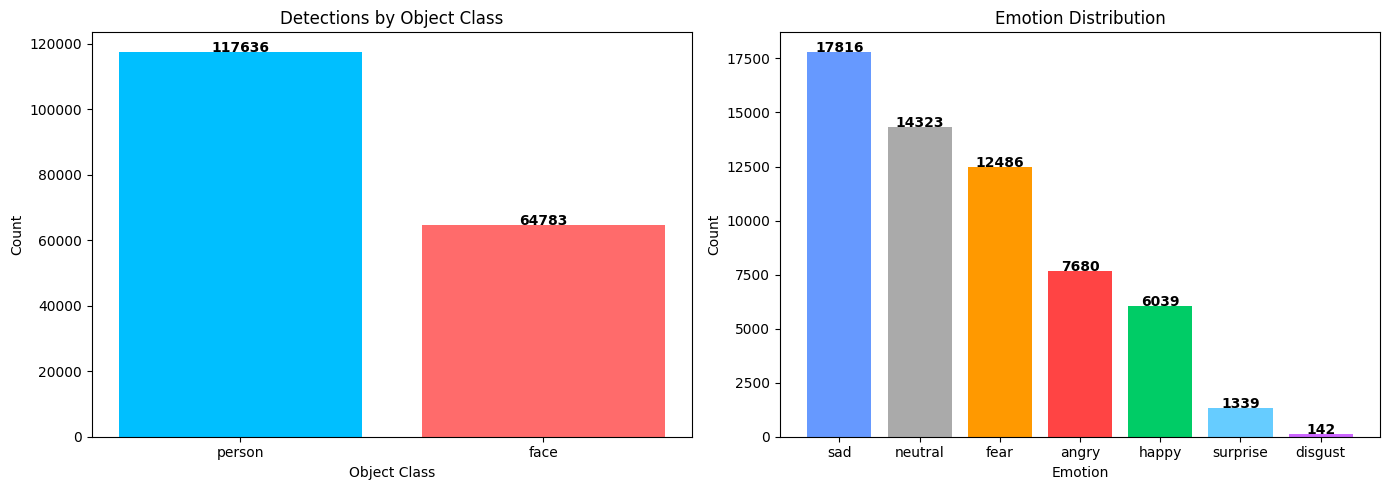

In [41]:
# ── BAR CHARTS ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Detections by object class
cursor.execute("""
    SELECT object_class, COUNT(*) as count
    FROM detection_events
    GROUP BY object_class
    ORDER BY count DESC
""")
class_data = cursor.fetchall()
class_labels = [row[0] for row in class_data]
class_counts = [row[1] for row in class_data]

axes[0].bar(class_labels, class_counts, color=["#00BFFF", "#FF6B6B", "#FFD700"])
axes[0].set_title("Detections by Object Class")
axes[0].set_xlabel("Object Class")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

# Chart 2 — Emotion distribution
cursor.execute("""
    SELECT emotion, COUNT(*) as count
    FROM emotion_events
    GROUP BY emotion
    ORDER BY count DESC
""")
emotion_data = cursor.fetchall()
emotion_labels = [row[0] for row in emotion_data]
emotion_counts = [row[1] for row in emotion_data]

emotion_colors = {
    "happy"   : "#00CC66",
    "surprise": "#66CCFF",
    "neutral" : "#AAAAAA",
    "sad"     : "#6699FF",
    "angry"   : "#FF4444",
    "fear"    : "#FF9900",
    "disgust" : "#CC66FF"
}
bar_colors = [emotion_colors.get(e, "#AAAAAA") for e in emotion_labels]

axes[1].bar(emotion_labels, emotion_counts, color=bar_colors)
axes[1].set_title("Emotion Distribution")
axes[1].set_xlabel("Emotion")
axes[1].set_ylabel("Count")
for i, v in enumerate(emotion_counts):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


### Testing/Debug

In [33]:
# ── SINGLE FRAME DETECTION CHECK ──────────────────────────────────────────
cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
ret, frame = cap.read()
cap.release()

h, w = frame.shape[:2]

blob = cv2.dnn.blobFromImage(
    frame, scalefactor=1.0/255.0,
    size=(INPUT_W, INPUT_H),
    mean=(0, 0, 0),
    swapRB=True, crop=False
)
peoplenet.setInput(blob)
output_layers = peoplenet.getUnconnectedOutLayersNames()
outputs       = peoplenet.forward(output_layers)

bbox_output = outputs[0]
cov_output  = outputs[1]

raw_detections = parse_peoplenet_detections(
    bbox_output, cov_output,
    PEOPLENET_CONFIDENCE_THRESHOLD,
    w, h
)
raw_detections = apply_nms(raw_detections, iou_threshold=0.3)

print(f"Total after NMS: {len(raw_detections)}")
for cls in ["person", "face", "bag"]:
    cls_dets = [d for d in raw_detections if d["object_class"] == cls]
    print(f"\n{cls}: {len(cls_dets)} detections")
    for d in cls_dets[:3]:
        b = d["bbox"]
        print(f"  conf={d['confidence']:.2f} "
              f"box=({b['x1']},{b['y1']}) -> ({b['x2']},{b['y2']}) "
              f"size={b['x2']-b['x1']}x{b['y2']-b['y1']}")

Total after NMS: 20

person: 12 detections
  conf=1.00 box=(419,488) -> (643,1079) size=224x591
  conf=0.99 box=(1572,496) -> (1721,893) size=149x397
  conf=0.99 box=(1415,478) -> (1565,905) size=150x427

face: 8 detections
  conf=1.00 box=(243,484) -> (308,561) size=65x77
  conf=0.99 box=(349,486) -> (389,537) size=40x51
  conf=0.99 box=(645,479) -> (684,527) size=39x48

bag: 0 detections


Verify results

In [ ]:
# ── DETECTION EVENTS ───────────────────────────────────────────────────────
print("=== DETECTION EVENTS (last 10) ===")
cursor.execute("""
    SELECT unique_detection_id, timestamp, object_class, confidence, zone_id
    FROM detection_events
    ORDER BY timestamp DESC
    LIMIT 10
""")
rows = cursor.fetchall()
print(f"{'ID':<6} {'Timestamp':<25} {'Class':<10} {'Conf':<8} {'Zone ID'}")
print("-" * 60)
for row in rows:
    print(f"{row[0]:<6} {str(row[1]):<25} {row[2]:<10} {row[3]:<8.2f} {row[4]}")

# ── EMOTION EVENTS ─────────────────────────────────────────────────────────
print("\n=== EMOTION EVENTS (last 10) ===")
cursor.execute("""
    SELECT e.unique_detection_id, d.timestamp, e.emotion, e.confidence
    FROM emotion_events e
    JOIN detection_events d ON e.unique_detection_id = d.unique_detection_id
    ORDER BY d.timestamp DESC
    LIMIT 10
""")
rows = cursor.fetchall()
print(f"{'Det ID':<8} {'Timestamp':<25} {'Emotion':<12} {'Confidence'}")
print("-" * 60)
for row in rows:
    print(f"{row[0]:<8} {str(row[1]):<25} {row[2]:<12} {row[3]:.2f}")

# ── EMOTION SUMMARY ────────────────────────────────────────────────────────
print("\n=== EMOTION SUMMARY ===")
cursor.execute("""
    SELECT emotion, COUNT(*) as count
    FROM emotion_events
    GROUP BY emotion
    ORDER BY count DESC
""")
rows = cursor.fetchall()
print(f"{'Emotion':<12} {'Count'}")
print("-" * 20)
for row in rows:
    print(f"{row[0]:<12} {row[1]}")

In [ ]:
cursor.close()
conn.close()
print("Database connection closed.")

# Notes for later

In [ ]:
# ── DEFINE ZONES ───────────────────────────────────────────────────────────
# Polygon coordinates will be filled in Cell 7 after drawing
# Add or edit zones here before running the inference loop

zones = [
    {
        "zone_name"           : "Entrance A",
        "camera_id"           : "CAM_01",
        "polygon_coordinates" : None,   # filled after Cell 7
        "floor"               : "L1",
        "zone_type"           : "entrance"
    },
    {
        "zone_name"           : "Restricted Corridor",
        "camera_id"           : "CAM_01",
        "polygon_coordinates" : None,   # filled after Cell 7
        "floor"               : "L1",
        "zone_type"           : "restricted"
    }
]

for zone in zones:
    cursor.execute("""
        INSERT INTO zones (zone_name, camera_id, polygon_coordinates, floor, zone_type)
        VALUES (%s, %s, %s, %s, %s)
        ON CONFLICT DO NOTHING
    """, (
        zone["zone_name"],
        zone["camera_id"],
        json.dumps(zone["polygon_coordinates"]),
        zone["floor"],
        zone["zone_type"]
    ))

conn.commit()
print("Zones inserted.")

# ── DEFINE RULES ───────────────────────────────────────────────────────────
rules = [
    {
        "rule_name"         : "intrusion_after_hours",
        "zone_name"         : "Restricted Corridor",
        "trigger_condition" : "person_detected = TRUE AND time BETWEEN '22:00' AND '06:00'",
        "threshold_min"     : None,
        "threshold_max"     : None,
        "severity"          : "critical",
        "rule_type"         : "security",
        "active"            : True
    },
    {
        "rule_name"         : "understaffed",
        "zone_name"         : "Entrance A",
        "trigger_condition" : "staff_count < threshold_min AND customer_count > threshold_max",
        "threshold_min"     : 3.0,
        "threshold_max"     : 10.0,
        "severity"          : "warning",
        "rule_type"         : "operations",
        "active"            : True
    }
]

for rule in rules:
    # Get zone_id from zone_name
    cursor.execute("SELECT zone_id FROM zones WHERE zone_name = %s", (rule["zone_name"],))
    zone_row = cursor.fetchone()
    if zone_row:
        cursor.execute("""
            INSERT INTO rules 
            (rule_name, zone_id, trigger_condition, threshold_min, threshold_max, severity, rule_type, active)
            VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
            ON CONFLICT DO NOTHING
        """, (
            rule["rule_name"],
            zone_row[0],
            rule["trigger_condition"],
            rule["threshold_min"],
            rule["threshold_max"],
            rule["severity"],
            rule["rule_type"],
            rule["active"]
        ))

conn.commit()
print("Rules inserted.")